![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_1/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  SVD en reconocimiento facial

En este caso-taller vamos a aplicar SVD para hacer reconocimiento facial. Esta aplicación se conoce como caras propias, o eigenfaces en inglés, y si bien es una forma rudimentaria de reconocimiento facial sus resultados pueden ser muy interesantes. El problema de las caras propias fue estudiado por primera vez por Sirovich y Kirby en 1987, ampliado en 1990 y su aplicación al reconocimiento facial automatizado fue presentado por Turk and Pentland en 1991.

En este taller vamos a utilizar la base de datos conocida como Caras Etiquetadas en la Naturaleza, o Labeled Faces in the Wild (LFW). Esta base es provista por la Universidad de Massachusetts Amherst para que la comunidad académica la utilice para la evaluación de modelos predictivos.

La base contiene más de 13.000 imágenes de rostros recopilados de la web y cada cara ha sido etiquetada con el nombre de la persona representada. Un subconjunto de 1.680 de las personas fotografiadas tienen dos o más fotos distintas en el conjunto de datos.



#### Referencias

- G. B. Huang,  M. Ramesh, T. Berg, and E. Learned-Miller. Labeled Faces in the Wild: A Database for Studying Face Recognition in Unconstrained Environments. University of Massachusetts, Amherst, Technical Report 07-49, October, 2007.

- M. Kirby and L. Sirovich. Application of the Karhunen-Loève procedure for the characterization of human faces. IEEE Transactions on Pattern Analysis and Machine Intelligence (PAMI), 12(1):103–108, 1990.

- L. Sirovich and M. Kirby. A low-dimensional procedure for the characterization of human faces. Journal of the Optical Society of America A, 4(3):519–524, 1987

- M. Turk and A. Pentland. Eigenfaces for recognition. Journal of Cognitive Neuroscience, 3(1):71–86, 1991.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.

## Desarrollo


### 1. Carga de datos

Los datos pueden ser descargados directamente utilizando la librería `scikit-learn`, para ello cargue la base utilizando la función `fetch_lfw_people`. Esta función verificará si los datos están disponibles. De no estarlo, `scikit-learn` los descargará automáticamente desde el sitio web de la Universidad de Massachusetts. Descargue las imágenes para individuos que tengan al menos 25 imágenes y guárdelos en una carpeta llamada `data` usando esta función.

In [12]:
import sys
!{sys.executable} -m pip install seaborn

import sys
!{sys.executable} -m pip install scikit-learn

import matplotlib.pyplot as plt

In [1]:
# Librerías
import seaborn as sns
import numpy as np
from sklearn.datasets import fetch_lfw_people

# Cargar datos
lfw = fetch_lfw_people(
    min_faces_per_person=25,
    resize=0.4,
    data_home="data"
)

# Ver información básica
print("Número de imágenes:", lfw.images.shape[0])
print("Tamaño de cada imagen:", lfw.images.shape[1:])
print("Número de variables (pixeles):", lfw.data.shape[1])
print("Número de personas:", len(lfw.target_names))

Número de imágenes: 2588
Tamaño de cada imagen: (50, 37)
Número de variables (pixeles): 1850
Número de personas: 42


Para el desarrollo del ejercicio se utilizó la base de datos Labeled Faces in the Wild (LFW), la cual fue cargada directamente desde la librería scikit-learn mediante la función fetch_lfw_people. En primer lugar, se importaron las librerías necesarias, incluyendo sklearn.datasets para acceder al conjunto de datos.

Posteriormente, se procedió a descargar y cargar la base de datos especificando algunos parámetros relevantes. En particular, se estableció min_faces_per_person = 25 con el fin de seleccionar únicamente aquellas personas que cuentan con al menos 25 imágenes, lo cual permite trabajar con un subconjunto más balanceado y adecuado para tareas de reconocimiento facial. Adicionalmente, se utilizó el parámetro resize = 0.4 para reducir el tamaño original de las imágenes, disminuyendo así la dimensión del problema y facilitando el procesamiento computacional.

Aunque se definió una ruta de almacenamiento (data_home), es importante señalar que, al trabajar en Google Colab, los datos se descargan en un entorno de almacenamiento temporal. Esto implica que los archivos no se conservan de manera permanente en la carpeta data ni se sincronizan automáticamente con GitHub, sino que permanecen disponibles únicamente durante la sesión activa.

### 2.  Análisis preliminar

Describa los contenidos de la base, tenga en cuenta que debe detallar los elementos, la dimensión de la base, y la dimensión de las imágenes.

In [13]:
#Elementos de la base de datos 
data = lfw.data # Matriz de la base de datos 
imagenes = lfw.images # Imagenes de la base
etiqueta = lfw.target #Etiquetas 
nom_etiquetas = lfw.target_names #Etiquetas numéricas 
lfw.DESCR

#Dimensiones de la base 
print(lfw.data.shape)

#Dimensión de las imágenes
print(lfw.images.shape)

print(lfw.images)

(2588, 1850)
(2588, 50, 37)
[[[0.16209151 0.2        0.22614379 ... 0.3633987  0.24444444 0.15686275]
  [0.18431373 0.22875817 0.28366014 ... 0.3869281  0.29411766 0.19477125]
  [0.19869281 0.2522876  0.32287583 ... 0.39607844 0.34901962 0.2509804 ]
  ...
  [0.703268   0.82222223 0.8078432  ... 0.16862746 0.15947713 0.13986929]
  [0.6640523  0.85882354 0.8666666  ... 0.17908497 0.17908497 0.17254902]
  [0.5869281  0.85751635 0.90326804 ... 0.1751634  0.17908497 0.18692811]]

 [[0.20130719 0.22091503 0.2522876  ... 0.42745098 0.3751634  0.3764706 ]
  [0.20784314 0.24052288 0.28366014 ... 0.44444445 0.3751634  0.35947713]
  [0.21830066 0.2653595  0.3137255  ... 0.45751634 0.37908497 0.351634  ]
  ...
  [0.09803922 0.0875817  0.06535948 ... 0.882353   0.85882354 0.66928107]
  [0.08888889 0.07712419 0.07712419 ... 0.89803916 0.85751635 0.6666667 ]
  [0.06797386 0.06535948 0.10326798 ... 0.9267974  0.8640523  0.6614379 ]]

 [[0.37254903 0.4        0.5411765  ... 0.51372546 0.38562095 0.3320

La base de datos Labeled Faces in the Wild (LFW) utilizada contiene un total de 2588 imágenes de rostros, cada una representada en dos formatos dentro de un objeto tipo *Bunch*. Por un lado, la matriz de datos (data) tiene dimensiones (2588, 1850), donde cada fila corresponde a una imagen transformada en un vector de 1850 características, equivalentes al número total de píxeles. Por otro lado, las imágenes conservan su estructura original en un *array* tridimensional (images) de dimensiones (2588, 50, 37), lo que indica que cada rostro tiene una resolución de 50 píxeles de alto por 37 de ancho. Adicionalmente, el conjunto incluye un vector de etiquetas (target) que asigna a cada imagen un identificador numérico, así como un arreglo (target_names) que contiene los nombres de las personas correspondientes a dichas etiquetas, y un campo (DESCR) que proporciona una descripción general del dataset. Esta estructura permite trabajar tanto con la representación visual de las imágenes como con su versión numérica para su análisis mediante técnicas de aprendizaje automático.

A continuación responda las siguientes preguntas:

- ¿Cuál es la distribución de imágenes por individuos?

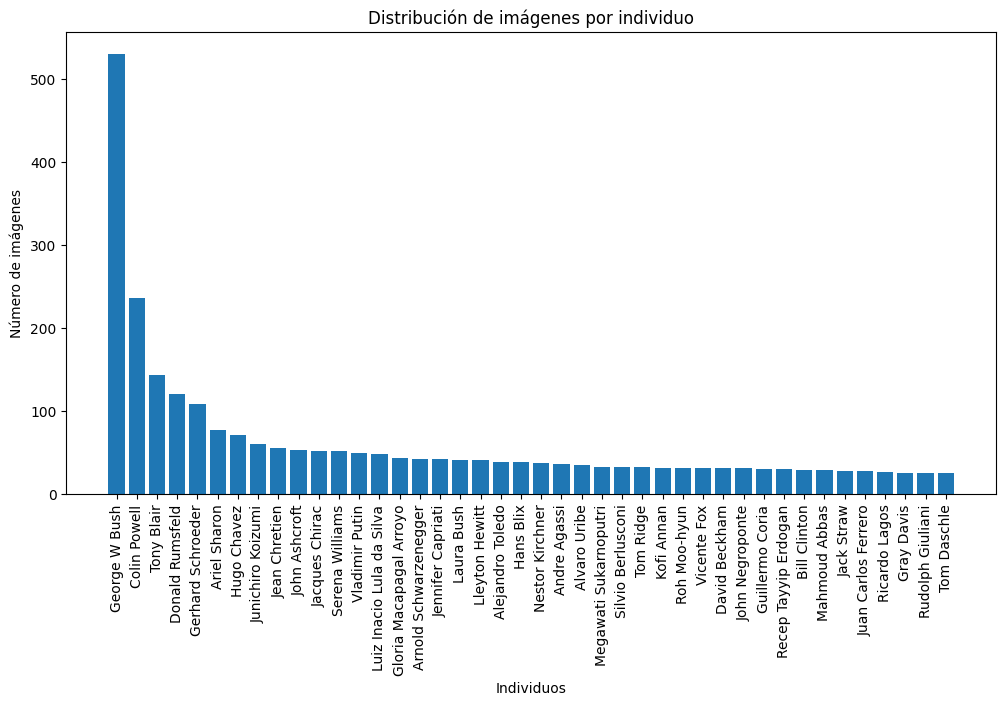

In [18]:
# contar imágenes por persona 
unique, counts = np.unique(etiqueta, return_counts=True)

#Ordenar de mayor a menor 
counts_sorted = sorted(zip(nom_etiquetas[unique], counts), key=lambda x: x[1], reverse=True)

names = [name for name, _ in counts_sorted]
values = [count for _, count in counts_sorted]

#Gráfico
plt.figure(figsize=(12,6))
plt.bar(names, values)
plt.xticks(rotation=90)
plt.title("Distribución de imágenes por individuo")
plt.xlabel("Individuos")
plt.ylabel("Número de imágenes")
plt.show()

La distribución de imágenes por individuo presenta un desbalance claro, donde algunos individuos concentran un número significativamente mayor de observaciones en comparación con el resto. En particular, se observa que George W. Bush cuenta con la mayor cantidad de imágenes, seguido por otros individuos con una representación considerablemente menor. A partir de ahí, la frecuencia decrece rápidamente, dando lugar a una larga cola de individuos con pocas imágenes. 

- ¿Cuántas imágenes pertenecen a Serena Williams? Grafíquelas

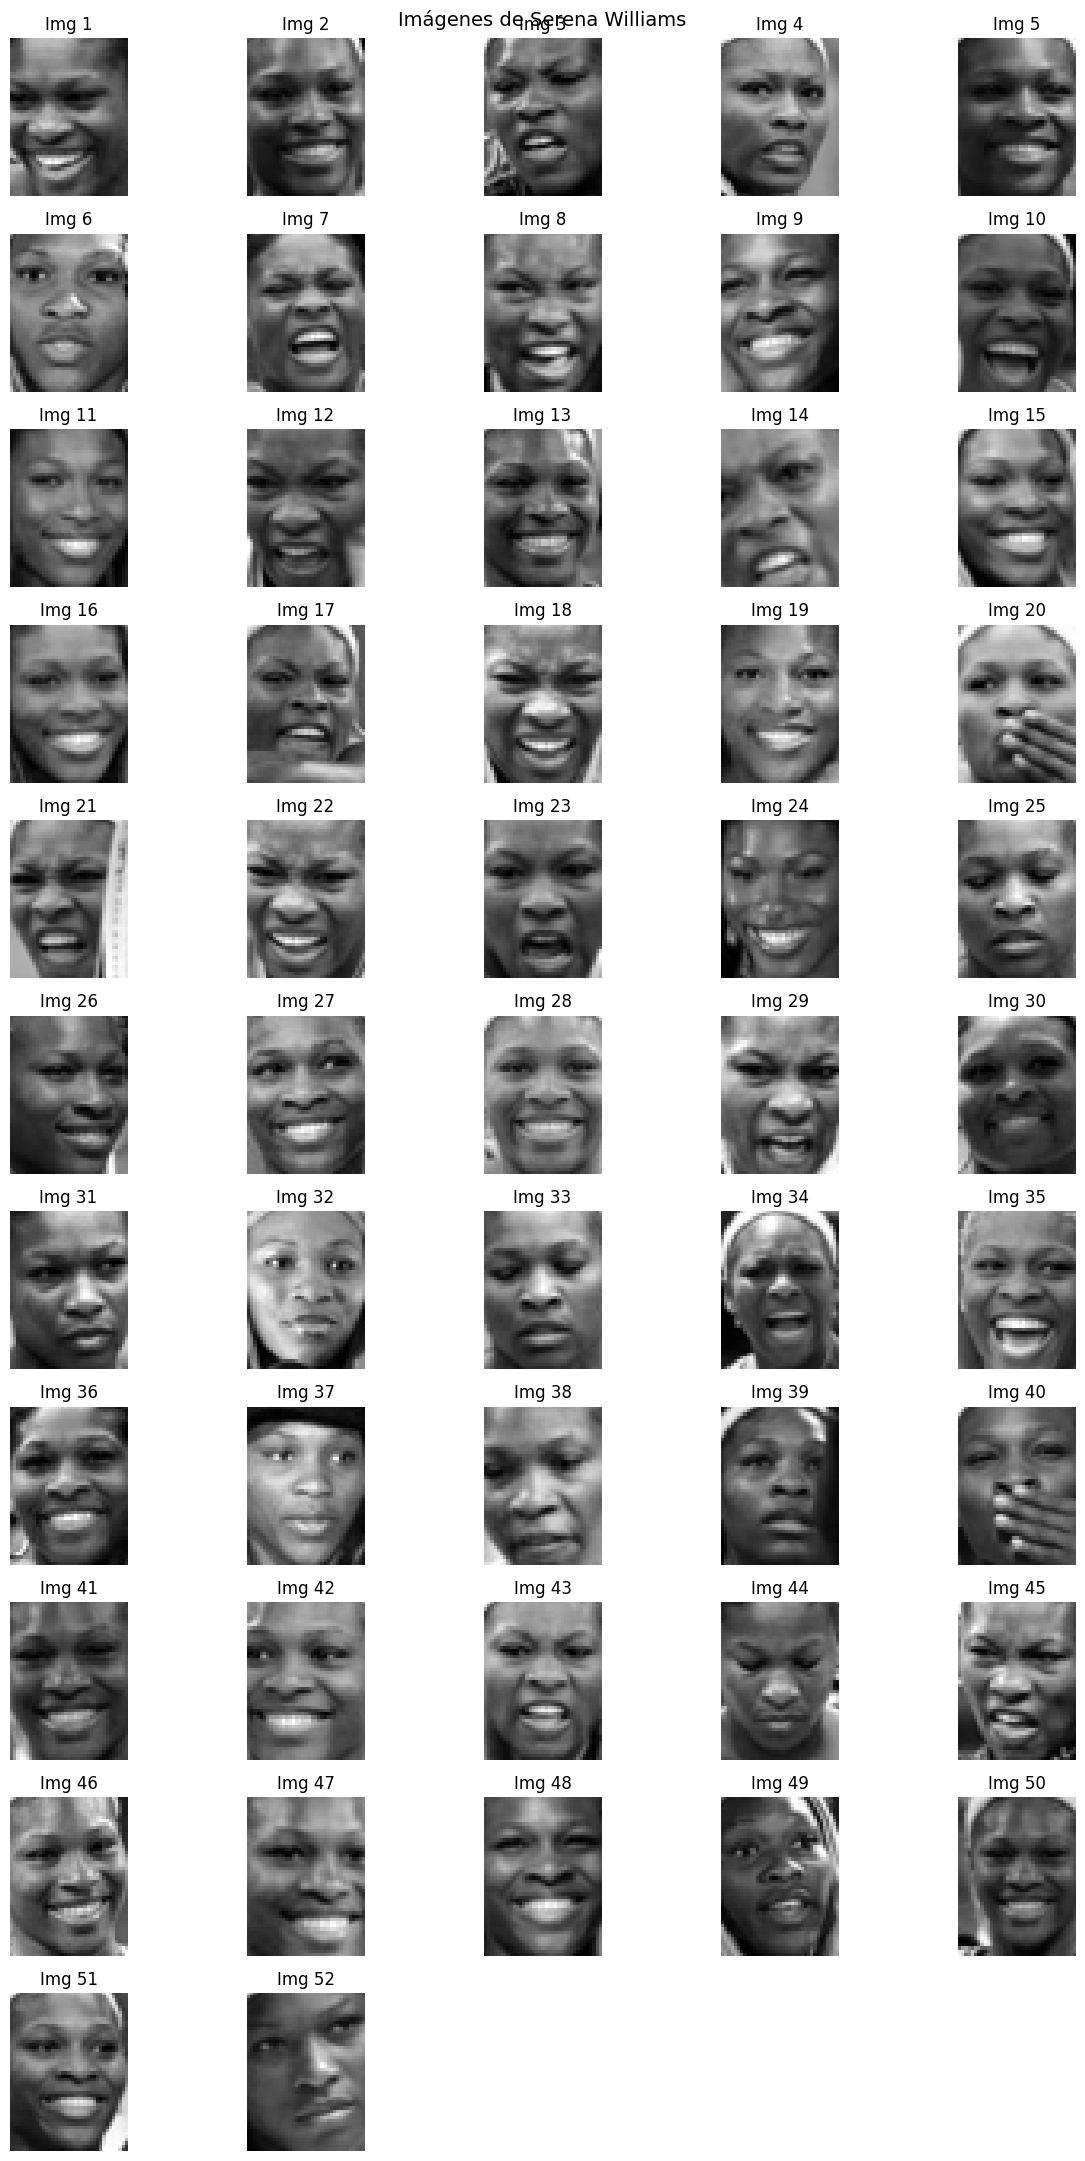

In [ ]:
#Buscar el índice que corresponde a Serena Williams 
serena_index = np.where(nom_etiquetas == 'Serena Williams')[0][0]

#Seleccionar las posiciones de las imágenes que pertenecen a Serena Williams 
serena_images_idx = np.where(etiqueta == serena_index)[0]

#Extraer las imagenes con las posiciones identificadas 
serena_images = imagenes[serena_images_idx]

#Definir la cantidad de imágenes a mostrar 
n_images = len(serena_images)

#Crear una figura para visualización 
cols = 5
rows = int(np.ceil(n_images / cols))
plt.figure(figsize=(12, 2 * rows))

#Graficar una por una de las imágenes 
for i, image in enumerate(serena_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title(f'Img {i+1}')

plt.suptitle('Imágenes de Serena Williams', fontsize=14)
plt.tight_layout()
plt.show()

Para graficar las imágenes de Serena Williams, primero se identifica la etiqueta numérica asociada a su nombre dentro de target_names. Luego, se localizan en target todas las observaciones que corresponden a esa etiqueta y, con esos índices, se extraen de images únicamente las imágenes de dicha persona. Finalmente, estas imágenes se visualizan mediante matplotlib en una cuadrícula, conservando su formato bidimensional y mostrándolas en escala de grises.

### 3.  Reconociendo rostros: las eigenfaces

Las eigenfaces son un conjunto de eigenvectors utilizados en el campo de la visión por computadora, principalmente en el reconocimiento de rostros. Son el resultado de reducir la dimensión de un gran conjunto de imágenes faciales, manteniendo la información que es más relevante para diferenciar las caras.

En este apartado buscaremos encontrar el espacio de menor dimensión manteniendo la información que es más relevante para diferenciar las caras. Lo haremos en etapas:


#### 3.1. Rostro promedio.

Encuentre primero el "rostro promedio" y grafíquelo.  Para encontrar este rostro, necesita calcular el valor promedio de los pixeles. (*Tip: Si X es la matriz donde las filas representan las imágenes  y en las columnas el tono de gris de los píxeles, debería calcular el promedio para cada una de las columnas*).


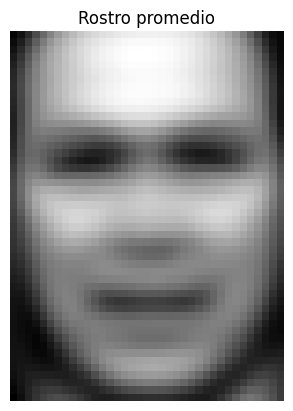

In [21]:
#Encontrar el promedio de cada pixel 
mean_face = np.mean(data, axis=0)

#convertir el vector a imagen
mf_image = mean_face.reshape(imagenes.shape[1], imagenes.shape[2])

#Grafica del rostro 
plt.imshow(mf_image, cmap='gray')
plt.title('Rostro promedio')
plt.axis('off')
plt.show()

El rostro promedio se obtiene calculando el promedio de cada píxel a través de todas las imágenes del conjunto de datos. Para ello, se utiliza la matriz de datos donde cada fila representa una imagen vectorizada y cada columna un píxel específico. Al promediar por columnas, se obtiene un vector que contiene el valor medio de cada píxel, el cual posteriormente se reorganiza en su forma bidimensional original para ser visualizado como una imagen. El resultado es una representación suavizada que captura las características faciales comunes presentes en la base de datos.

#### 3.2. Reste el rostro promedio.

A cada una de las imágenes, reste el rostro promedio, es decir, reste la media a cada columna. Grafique las imágenes de Serena Williams luego de quitarle el rostro promedio.

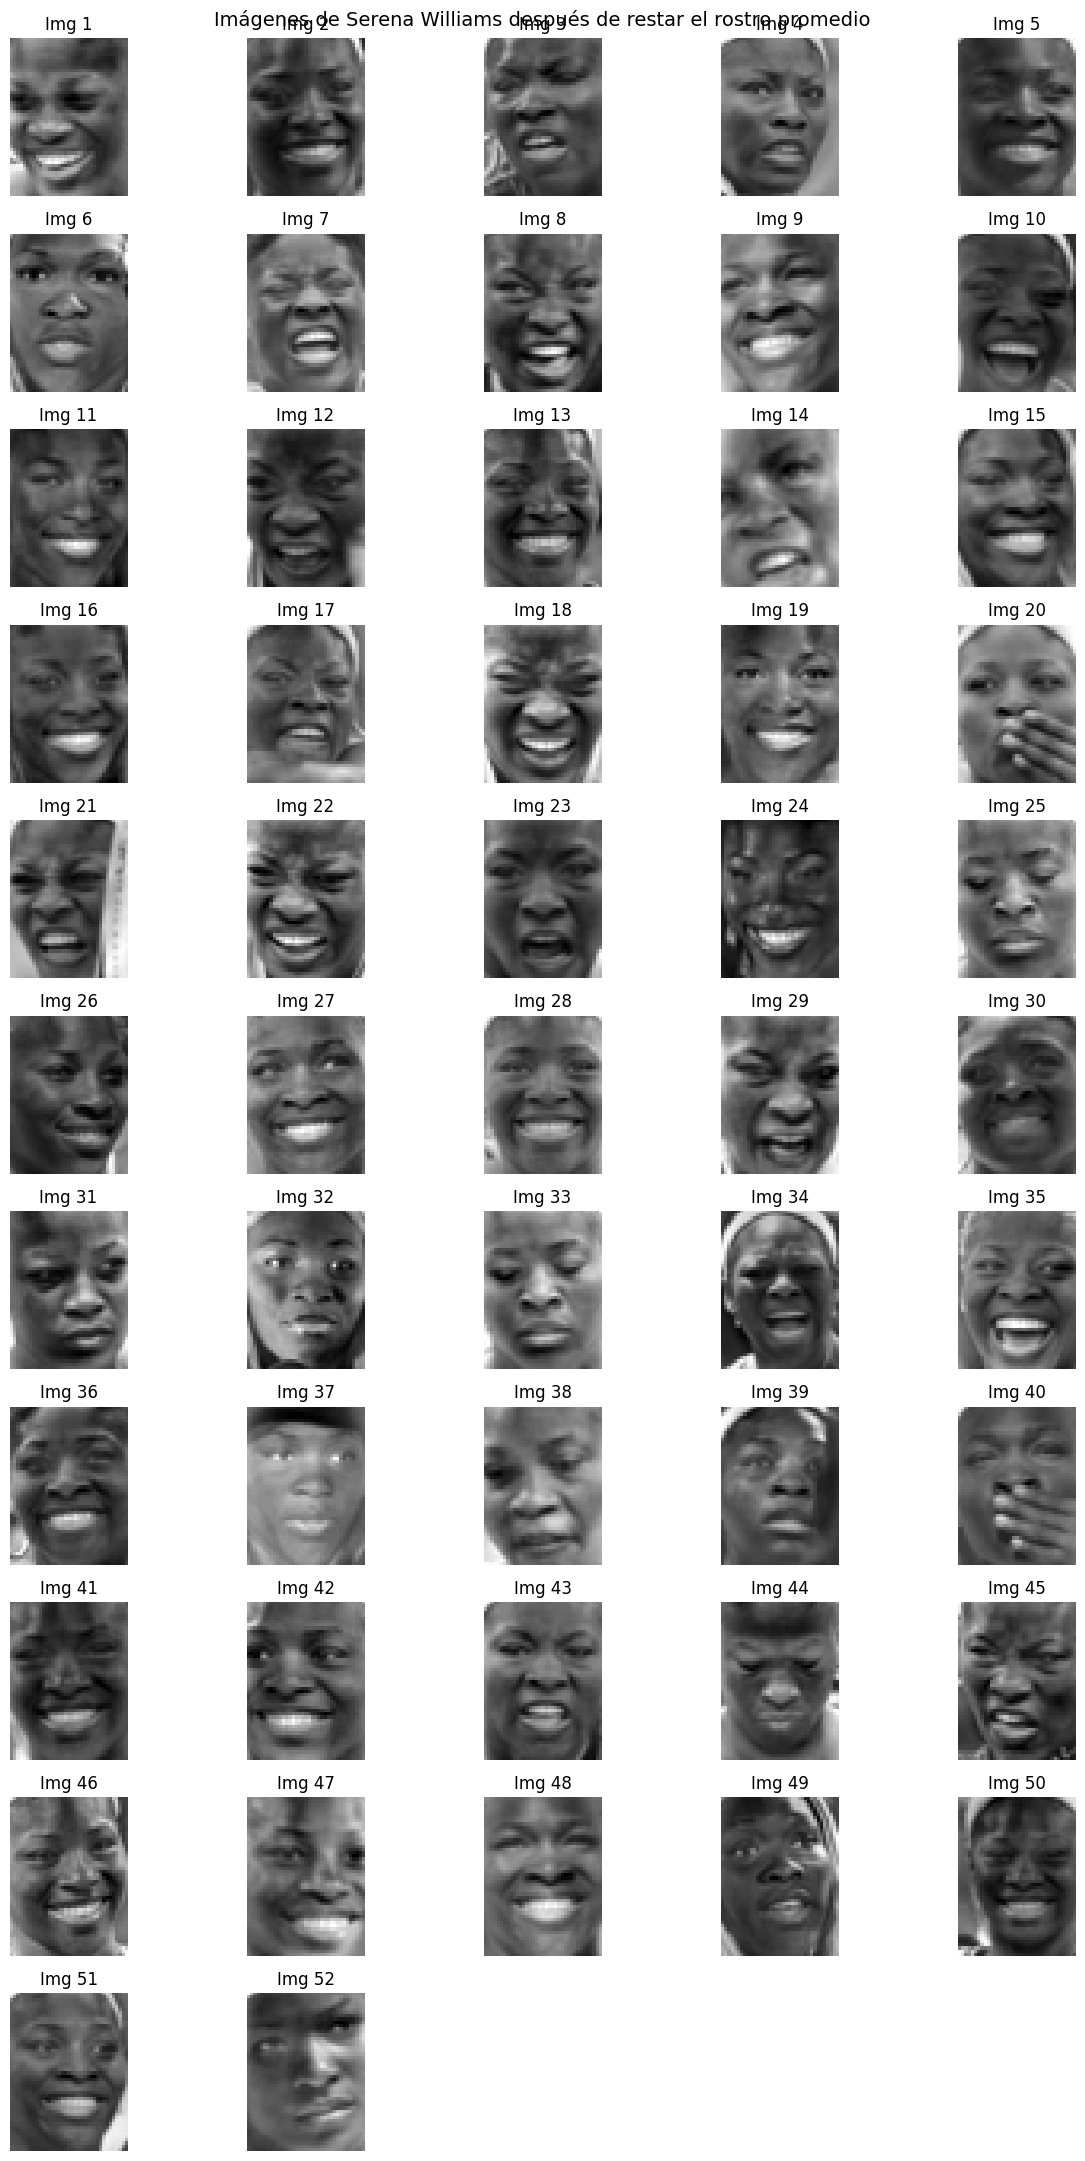

In [22]:
#Calcular media 
mean_face = np.mean(data, axis=0)

#Restar el rostro promedio a cada imagen
wo_mean = data - mean_face

#Identificar el índice de Serena Williams 
serena_index = np.where(nom_etiquetas == 'Serena Williams')[0][0]

#Encontrar las filas que corresponden a Serena Williams
serena_idx = np.where(etiqueta == serena_index)[0]
serena_wo_mean = wo_mean[serena_idx]

#Graficarlas 
cols = 5
rows = int(np.ceil(len(serena_wo_mean) / cols))

plt.figure(figsize=(12, 2 * rows))

for i, img in enumerate(serena_wo_mean):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img.reshape(50, 37), cmap='gray')
    plt.axis('off')
    plt.title(f'Img {i+1}')

plt.suptitle('Imágenes de Serena Williams después de restar el rostro promedio', fontsize=14)
plt.tight_layout()
plt.show()

Para recrear las imágenes sin el rostro promedio,primero se calculó el rostro promedio del conjunto de datos tomando el promedio de los valores de cada píxel. Posteriormente, este rostro promedio se restó a cada una de las imágenes, con el objetivo de eliminar las características comunes y resaltar las diferencias individuales. A partir de esta nueva representación, se seleccionaron las imágenes correspondientes a Serena Williams y se graficaron. Las imágenes resultantes no muestran el rostro de forma convencional, sino las variaciones respecto al promedio del conjunto de datos, lo que permite identificar qué rasgos se apartan del patrón general.

#### 3.3. Descomposición en Valores Singulares

Aplique la Descomposición en Valores Singulares a estas nuevas imágenes y retenga solo $K=1000$ valores singulares ¿Qué proporción de la varianza representan estos valores singulares?

In [24]:
from scipy.linalg import svd

#Aplicar SVD 
U, S, VT = np.linalg.svd(wo_mean, full_matrices=False)

#Retener los 1000 valores singulares
K = 1000

# Proporción de varianza explicada
var_explained_1000 = np.sum(S[:K]**2) / np.sum(S**2)

print("Proporción de varianza explicada por los primeros 1000 valores singulares:")
print(var_explained_1000)

Proporción de varianza explicada por los primeros 1000 valores singulares:
0.9989514


Para analizar la información contenida en las imágenes sin el rostro promedio, se aplicó la descomposición en valores singulares sobre la matriz resultante después de restar el rostro promedio. Luego, se conservaron los primeros 1000 valores singulares, que corresponden a las direcciones que concentran la mayor parte de la variabilidad de los datos. La proporción de varianza explicada se calculó como la suma de los cuadrados de estos 1000 valores singulares dividida por la suma de los cuadrados de todos los valores singulares. Este resultado permite medir qué tan bien se representa la información original al conservar solo una parte de los componentes. En este caso, los primeros 1000 valores singulares explican aproximadamente el 99,8% de la varianza total del conjunto de imágenes. 

#### 3.4. Representando los rostros en las bases

Las eigenfaces nos dice que cada rostro puede ser representado a partir de la aproximación a la matriz original por la matriz de dimensión reducida determinada en el punto anterior más el rostro promedio. Muestre que esto es posible para las imágenes de Serena Williams. Compare las imágenes reconstruidas con las originales.

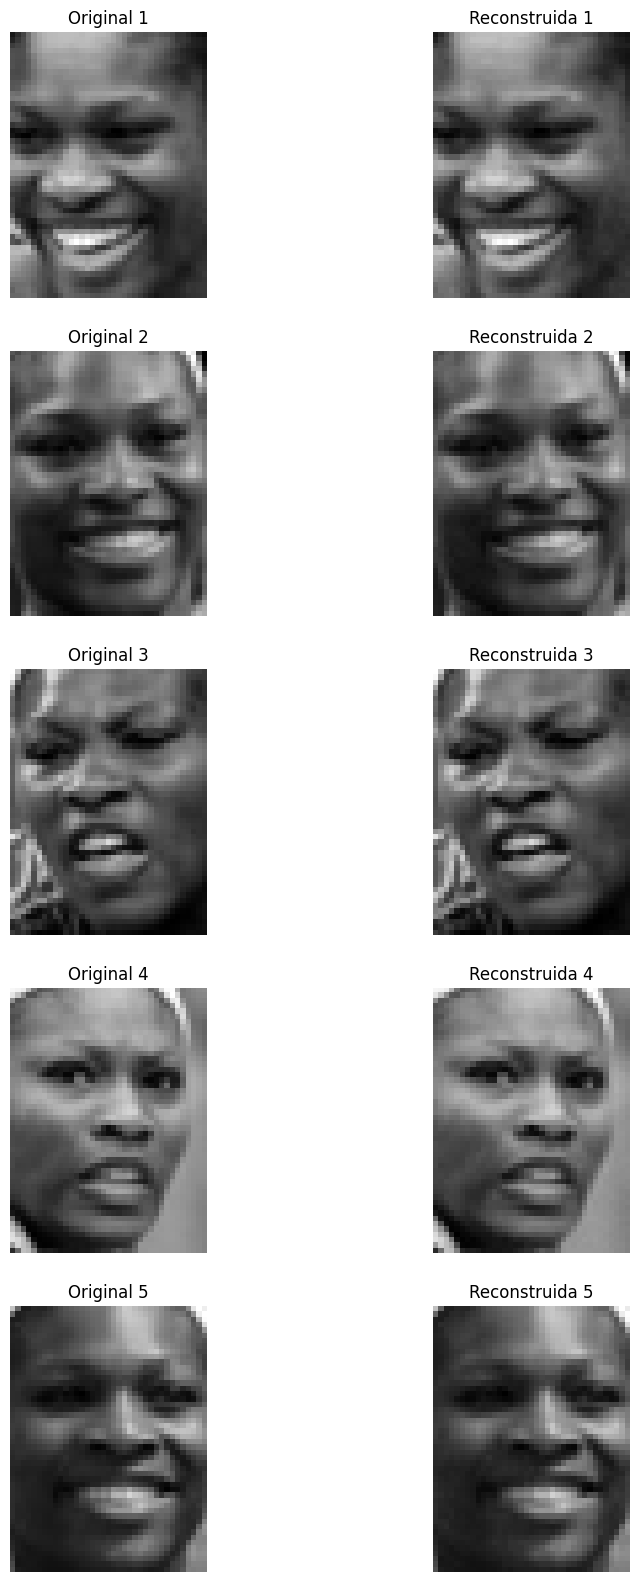

In [25]:
# Hacer la aproximación de rango k
U_k = U[:, :K]
S_k = S[:K]
VT_k = VT[:K, :]

face_aprox = U_k @ np.diag(S_k) @ VT_k

# Sumar el rostro promedio para volver a la escala original
face_recon = face_aprox + mean_face

# 9. Tomar algunas imágenes de Serena para comparar
n_show = min(5, len(serena_idx))

plt.figure(figsize=(10, 4 * n_show))

for i in range(n_show):
    idx = serena_idx[i]
    
    # Imagen original
    original = data[idx].reshape(50, 37)
    
    # Imagen reconstruida
    reconstructed = face_recon[idx].reshape(50, 37)
    
    # Graficar original
    plt.subplot(n_show, 2, 2*i + 1)
    plt.imshow(original, cmap='gray')
    plt.title(f'Original {i+1}')
    plt.axis('off')
    
    # Graficar reconstruida
    plt.subplot(n_show, 2, 2*i + 2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f'Reconstruida {i+1}')
    plt.axis('off')

Para verificar que los rostros pueden representarse a partir de los eigenfaces, se reconstruyeron las imágenes de Serena Williams usando la aproximación de rango reducido obtenida mediante SVD con 𝑘 = 1000 componentes. En primer lugar, se trabajó con las imágenes después de restar el rostro promedio. Luego, se reconstruyó una versión aproximada de la matriz original utilizando únicamente los primeros 1000 valores singulares y, finalmente, se sumó nuevamente el rostro promedio para recuperar la escala original de las imágenes. Al comparar las imágenes reconstruidas con las originales, se observa que la aproximación conserva de manera adecuada la estructura general del rostro. Esto muestra que una parte importante de la información facial puede resumirse en un número reducido de componentes.

### 4. Uniendo Aprendizaje No Supervisado y Supervisado

Dado que cada rostro puede ser representado por las eigenfaces, y la relación que existe entre componentes principales y la SVD, esto sugiere que los componentes principales aquí determinados pueden servir de insumo para un algoritmo de clasificación de aprendizaje supervisado. En este sección del taller haremos esto.

Para ello construiremos un modelo de clasificación logístico para predecir si la imagen pertenece a `George W Bush`  (el individuo con más imágenes en la base)  o no.

#### 4.1. Identificando a `George W Bush`

Cree una variable binaria que tome el valor 1 si la imagen pertenece a `George W Bush` y 0 en caso contrario.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 4.2. Bases de Entrenamiento y Prueba.

Divida la base utilizada anteriormente en dos: 80% de la base de imágenes asígnelas a la base de entrenamiento y el 20% restante a la de prueba, utilice un `random_state=10101`.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 4.3. Descomposición en Valores Singulares

Para la base de entrenamiento y de prueba, realice la descomposición en valores singulares (Recuerde recentrar las matrices para que tenga media 0).

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 4.4. Estimación de modelo de aprendizaje supervisado


Utilizando $k=1000$ valores singulares, construya los 1000 primeros componentes principales y úselos como predictores en su modelo logístico. Utilice como métrica de performance el porcentaje de imágenes de `George W Bush` clasificadas correctamente.

Para estimar su modelo logístico Utilice el `solver='sag`,`random_state=10101` y `max_iter=1000`. Como se muestra a continuación:



In [ ]:
from sklearn.linear_model import LogisticRegression

Modelo_Logistico = LogisticRegression(solver='sag',random_state=10101,max_iter=1000)

# Utilice este espacio para escribir el código restante.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 4.5. Mejorando el Ajuste

Trate ahora el número de valores singulares como un hiper-parámetro a encontrar. Emplee validación cruzada con 5 o 10 folds (dependiendo de su poder computacional) para encontrar el número óptimo de valores singulares. Con este modelo, evalúe el porcentaje de imágenes de `George W Bush` clasificadas correctamente en su muestra de prueba. Compare y discuta esta forma de elegir el número de variables con aquella utilizada en  4.4. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).